# 06f · GSE65391 · RNA_array · patient-group profiles with our methods: Ward trees and k-means

Reads `pg_profiles.rds` (notebook 06d) and `pg_paper_groups.csv` (notebook 06e).

**Two profiles, side by side** (notebook 06d), one row per child:
- `net5`: SLEDAI correlation with the paper's five networks (797 probes);
- `mod16`: SLEDAI correlation with our 16 array modules.

**Methods, as in notebooks 06a and 07.**
- Ward's method (`ward.D2`; Ward JH. *J Am Stat Assoc* 1963;58:236–244; Murtagh F, Legendre P. *J Classif*
  2014;31:274–295) on Minkowski distance with p = 2, children and features. **Trees not cut.**
- The gap statistic (Tibshirani R, Walther G, Hastie T. *J R Stat Soc B* 2001;63:411–423) for **k-means
  only**, on the children: `cluster::clusGap`, k = 1 to 8, B = 500, d.power = 2, spaceH0 = "scaledPCA",
  rule Tibs2001SEmax, 50 random starts. k = 1 means no groups.

The seven groups rebuilt in notebook 06e are shown as a strip, for reading only.

**Test.** Does either profile show groups of children (gap statistic k > 1)? If it does, is k near 7?

In [1]:
source("../src/paths.R")
suppressMessages({library(cluster); library(ComplexHeatmap); library(circlize)})
pg <- readRDS(art("GSE65391", "pg_profiles.rds"))
paper7 <- read.csv(art("GSE65391", "pg_paper_groups.csv"))
g7 <- factor(paper7$group[match(rownames(pg$net5), paper7$subject)])
profiles <- list(net5 = pg$net5, mod16 = pg$mod16)
sapply(profiles, dim)

net5,mod16
83,83
5,16


In [2]:
set.seed(SEED)
gaps <- lapply(profiles, function(P) clusGap(P, FUNcluster = kmeans, K.max = 8, B = 500, d.power = 2,
                                             spaceH0 = "scaledPCA", nstart = 50, iter.max = 50, verbose = FALSE))
sapply(gaps, function(g) maxSE(g$Tab[, "gap"], g$Tab[, "SE.sim"], method = "Tibs2001SEmax"))
lapply(gaps, function(g) round(g$Tab[, c("gap", "SE.sim")], 3))

net5 mod16 
    1     1

gap,SE.sim
0.785,0.060
0.773,0.058
0.654,0.052
0.620,0.048
0.665,0.047
0.665,0.048
0.678,0.049
0.688,0.050
gap,SE.sim
0.760,0.041


**Result: no groups of children.** The gap statistic gives k = 1 for both profiles: no k from 2 to 8
improves on one group by more than its standard error (five networks: Gap 0.785 at k = 1, 0.773 at k = 2;
16 modules: 0.760 at k = 1, 0.738 at k = 2). k-means therefore finds no groups, seven or any other number.

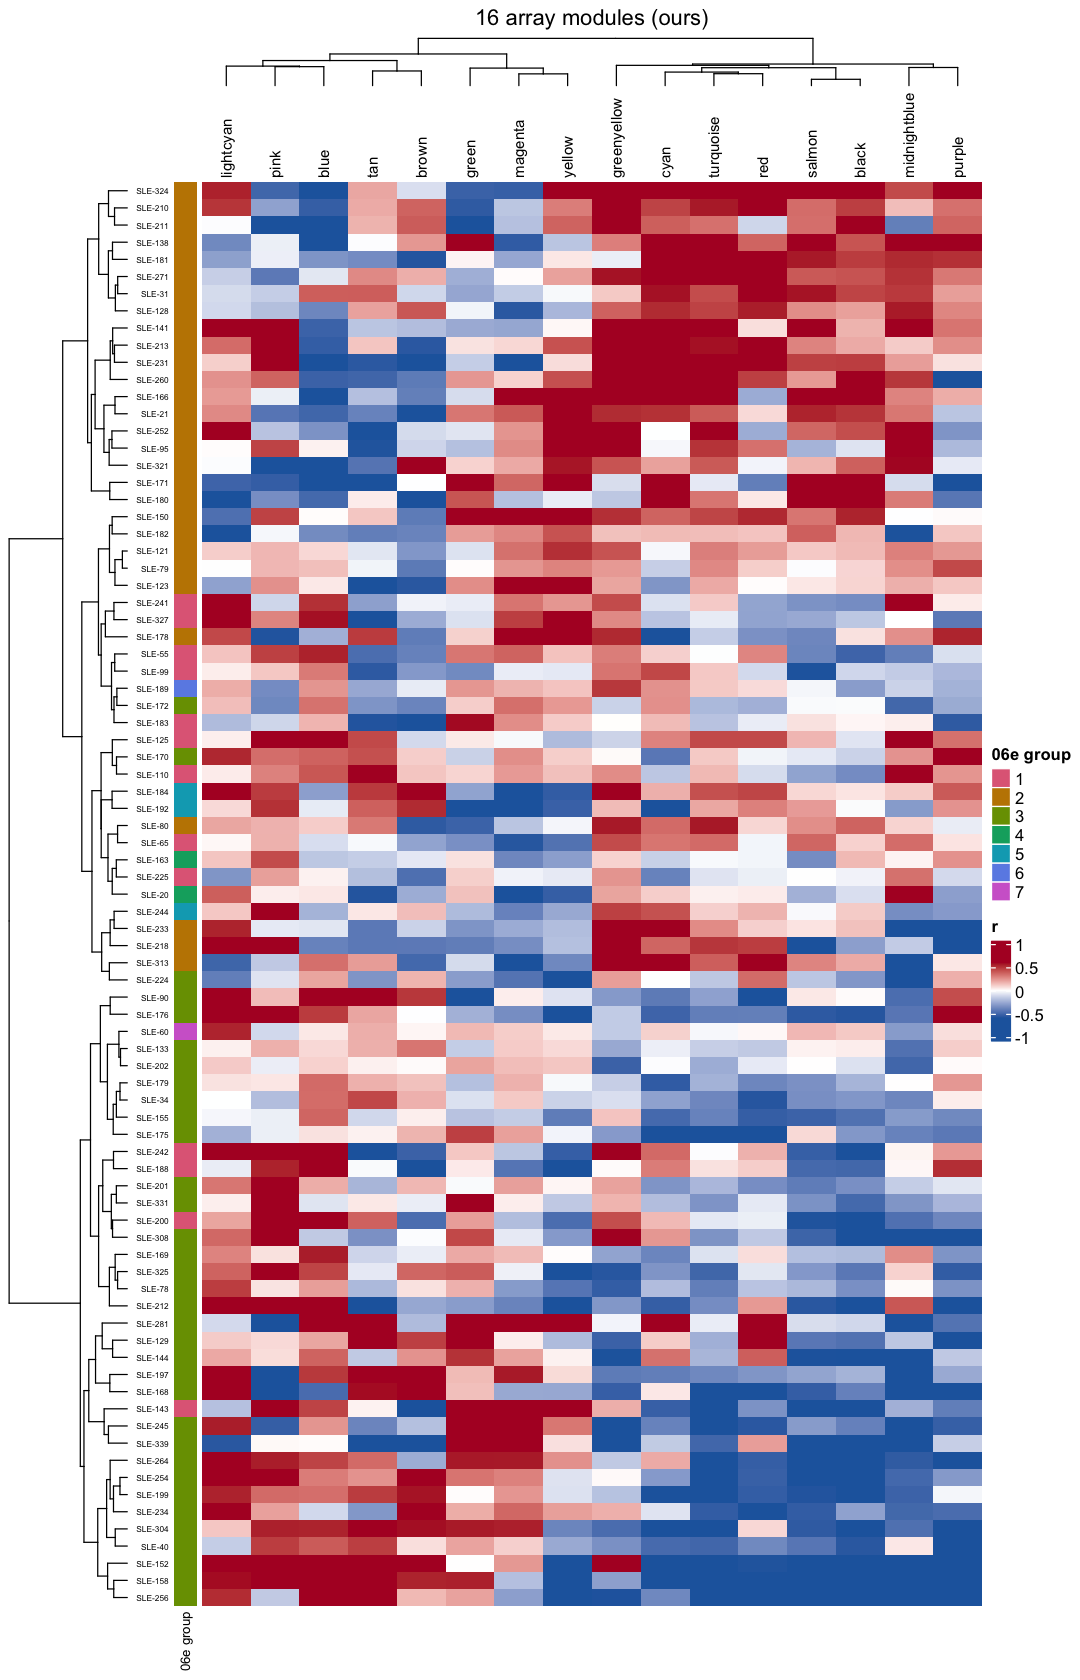

In [3]:
heat <- function(P, title, cols) {
  Heatmap(P, name = "r", col = colorRamp2(c(-0.6, 0, 0.6), c("#2166AC", "white", "#B2182B")),
          clustering_distance_rows = function(m) dist(m, method = "minkowski", p = 2), clustering_method_rows = "ward.D2",
          clustering_distance_columns = function(m) dist(m, method = "minkowski", p = 2), clustering_method_columns = "ward.D2",
          cluster_columns = cols,
          row_dend_side = "left", column_dend_side = "top", row_dend_width = unit(25, "mm"),
          show_row_names = TRUE, row_names_side = "left", row_names_gp = gpar(fontsize = 5),
          column_names_side = "top", column_names_gp = gpar(fontsize = 9),
          left_annotation = rowAnnotation(`06e group` = g7, col = list(`06e group` = setNames(hcl.colors(7, "Dark 3"), levels(g7))),
                                          annotation_name_gp = gpar(fontsize = 8)),
          column_title = title)
}
options(repr.plot.width = 9, repr.plot.height = 14)
for (nm in names(profiles)) {                        # one figure per profile, each with its own Ward trees
  figure <- function() heat(profiles[[nm]], c(net5 = "five networks (paper's 797 probes)", mod16 = "16 array modules (ours)")[[nm]], TRUE)
  for (device in c("inline", "png")) {             # shown here, and saved as a 300 dpi PNG
    if (device == "png") png(fig("GSE65391", paste0("06f_PG_ward_", nm, ".png")), width = 9, height = 14, units = "in", res = 300)
    out <- figure(); if (inherits(out, c("Heatmap", "HeatmapList"))) draw(out)
    if (device == "png") invisible(dev.off())
  }
}

**Reading the figures.** The Ward trees are drawn whole and not cut; the strip marks the groups of
notebook 06e, for reading only. In both figures the two largest 06e groups sit at opposite ends of the
tree:
- group 2 at the top, where the plasma-cell and lymphoid networks (our greenyellow, cyan and turquoise
  modules) rise with SLEDAI;
- group 3 at the bottom, where interferon, myeloid or erythropoiesis rise and plasma-cell and lymphoid fall.

Group 1 and the small groups lie between them. The profiles run from one pattern to the other, and the gap
statistic finds no point along that range where the children separate into groups.